In [44]:

# ============================================================
# 1. Imports + configuration
# ============================================================

import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from skimage.metrics import (
    mean_squared_error,
    peak_signal_noise_ratio,
    structural_similarity
)

import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)


IMAGE_PATHS = [
    "/content/ct_clean.png",
    "/content/ct2.png",
    "/content/baby.png",
]

IMAGE_NAMES = [
    "Image 1",
    "Image 2",
    "Image 3",
]

TARGET_SIZE = (512, 512)

# Gaussian frequency-domain bandwidth degradation
GAUSSIAN_SIGMA_FRACTION = 0.25

# Additive Gaussian noise
NOISE_STD = 0.01
RANDOM_SEED = 42

assert len(IMAGE_PATHS) == 3, "Please provide exactly THREE image paths."

print("\nConfiguration")
print("-------------")
print("Target size:", TARGET_SIZE)
print("Gaussian sigma fraction:", GAUSSIAN_SIGMA_FRACTION)
print("Noise STD:", NOISE_STD)
print("VDSR input:", "512 x 512 noisy low-bandwidth image")


PyTorch: 2.11.0+cpu
Device: cpu

Configuration
-------------
Target size: (512, 512)
Gaussian sigma fraction: 0.25
Noise STD: 0.01
VDSR input: 512 x 512 noisy low-bandwidth image


In [45]:

# ============================================================
# 2. Download pretrained VDSR
# ============================================================

!rm -rf /content/pytorch-vdsr

!git clone -q \
    https://github.com/twtygqyy/pytorch-vdsr.git \
    /content/pytorch-vdsr

sys.path.insert(0, "/content/pytorch-vdsr")

import vdsr

print("✓ VDSR repository downloaded")
print("✓ vdsr module imported")


✓ VDSR repository downloaded
✓ vdsr module imported


In [46]:

# ============================================================
# 3. Load pretrained VDSR
# ============================================================

WEIGHTS = (
    "/content/pytorch-vdsr/"
    "model/model_epoch_50.pth"
)

checkpoint = torch.load(
    WEIGHTS,
    map_location="cpu",
    weights_only=False
)

model = checkpoint["model"].to(DEVICE)
model.eval()

print("✓ Pretrained VDSR loaded")
print(model)

# Count parameters
num_params = sum(p.numel() for p in model.parameters())

print(f"\nVDSR parameters: {num_params:,}")


✓ Pretrained VDSR loaded
Net(
  (residual_layer): Sequential(
    (0): Conv_ReLU_Block(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (relu): ReLU(inplace=True)
    )
    (1): Conv_ReLU_Block(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (relu): ReLU(inplace=True)
    )
    (2): Conv_ReLU_Block(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (relu): ReLU(inplace=True)
    )
    (3): Conv_ReLU_Block(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (relu): ReLU(inplace=True)
    )
    (4): Conv_ReLU_Block(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (relu): ReLU(inplace=True)
    )
    (5): Conv_ReLU_Block(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (relu): ReLU(inplace=True)
  

In [47]:

# ============================================================
# 4. Processing functions
# ============================================================

def load_grayscale_512(path):
    """Load image as grayscale and resize to exactly 512x512."""
    image = Image.open(path).convert("L")

    # image = image.resize(
    #     TARGET_SIZE,
    #     Image.Resampling.BICUBIC
    # )

    arr = np.asarray(
        image,
        dtype=np.float32
    ) / 255.0

    return arr


def gaussian_lowpass_ct(
    image,
    sigma_fraction=0.25
):
    """
    Frequency-domain Gaussian low-pass degradation.

    Input:
        H x W clean image

    Output:
        H x W low-bandwidth image
        H x W Gaussian frequency mask
    """

    h, w = image.shape

    F_img = np.fft.fftshift(
        np.fft.fft2(image)
    )

    fy = np.fft.fftshift(
        np.fft.fftfreq(h)
    )

    fx = np.fft.fftshift(
        np.fft.fftfreq(w)
    )

    FX, FY = np.meshgrid(fx, fy)

    radius = np.sqrt(FX**2 + FY**2)

    # sigma is expressed relative to the Nyquist frequency (= 0.5 cycles/pixel)
    sigma = sigma_fraction * 0.5

    gaussian_mask = np.exp(
        -(radius**2) / (2 * sigma**2)
    )

    F_filtered = F_img * gaussian_mask

    filtered = np.fft.ifft2(
        np.fft.ifftshift(F_filtered)
    ).real

    filtered = np.clip(
        filtered,
        0.0,
        1.0
    ).astype(np.float32)

    return filtered, gaussian_mask


def add_gaussian_noise(
    image,
    noise_std,
    seed
):
    rng = np.random.default_rng(seed)

    noise = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=image.shape
    ).astype(np.float32)

    noisy = np.clip(
        image + noise,
        0.0,
        1.0
    ).astype(np.float32)

    return noisy, noise




def power_spectrum(image):
    """Log-free power spectrum."""
    F = np.fft.fftshift(
        np.fft.fft2(image)
    )
    return np.abs(F) ** 2


def log_power_spectrum(image):
    return np.log1p(
        power_spectrum(image)
    )


def evaluate_image(reference, image):
    mse = mean_squared_error(
        reference,
        image
    )

    psnr = peak_signal_noise_ratio(
        reference,
        image,
        data_range=1.0
    )

    ssim = structural_similarity(
        reference,
        image,
        data_range=1.0
    )

    return mse, psnr, ssim


print("✓ Functions defined")


✓ Functions defined


In [48]:

# ============================================================
# 5. Load THREE images + create all degraded versions
# ============================================================

data = []

for idx, (path, name) in enumerate(
    zip(IMAGE_PATHS, IMAGE_NAMES)
):

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Image not found: {path}\n"
            "Please update IMAGE_PATHS in Cell 1."
        )

    clean = load_grayscale_512(path)

    low_bandwidth, gaussian_mask = gaussian_lowpass_ct(
        clean,
        GAUSSIAN_SIGMA_FRACTION
    )

    noisy_low_bandwidth, noise = add_gaussian_noise(
        low_bandwidth,
        NOISE_STD,
        RANDOM_SEED + idx
    )

    item = {
        "name": name,
        "path": path,
        "clean": clean,
        "low_bandwidth": low_bandwidth,
        "noise": noise,
        "noisy_low_bandwidth": noisy_low_bandwidth,
        "gaussian_mask": gaussian_mask
    }

    data.append(item)


print("✓ Three images processed")
print()

# Print the objects/shapes so you can see exactly what is going into VDSR.
for item in data:
    print("=" * 65)
    print(item["name"])
    print("Path:", item["path"])
    print("clean                 :", item["clean"].shape)
    print("low_bandwidth         :", item["low_bandwidth"].shape)
    print("noise                 :", item["noise"].shape)
    print("noisy_low_bandwidth   :", item["noisy_low_bandwidth"].shape)
    print("Min/Max noisy input   :",
          item["noisy_low_bandwidth"].min(),
          item["noisy_low_bandwidth"].max())


✓ Three images processed

Image 1
Path: /content/ct_clean.png
clean                 : (512, 512)
low_bandwidth         : (512, 512)
noise                 : (512, 512)
noisy_low_bandwidth   : (512, 512)
Min/Max noisy input   : 0.0 0.5784043
Image 2
Path: /content/ct2.png
clean                 : (512, 512)
low_bandwidth         : (512, 512)
noise                 : (512, 512)
noisy_low_bandwidth   : (512, 512)
Min/Max noisy input   : 0.0 0.68905824
Image 3
Path: /content/baby.png
clean                 : (512, 512)
low_bandwidth         : (512, 512)
noise                 : (512, 512)
noisy_low_bandwidth   : (512, 512)
Min/Max noisy input   : 0.0 1.0


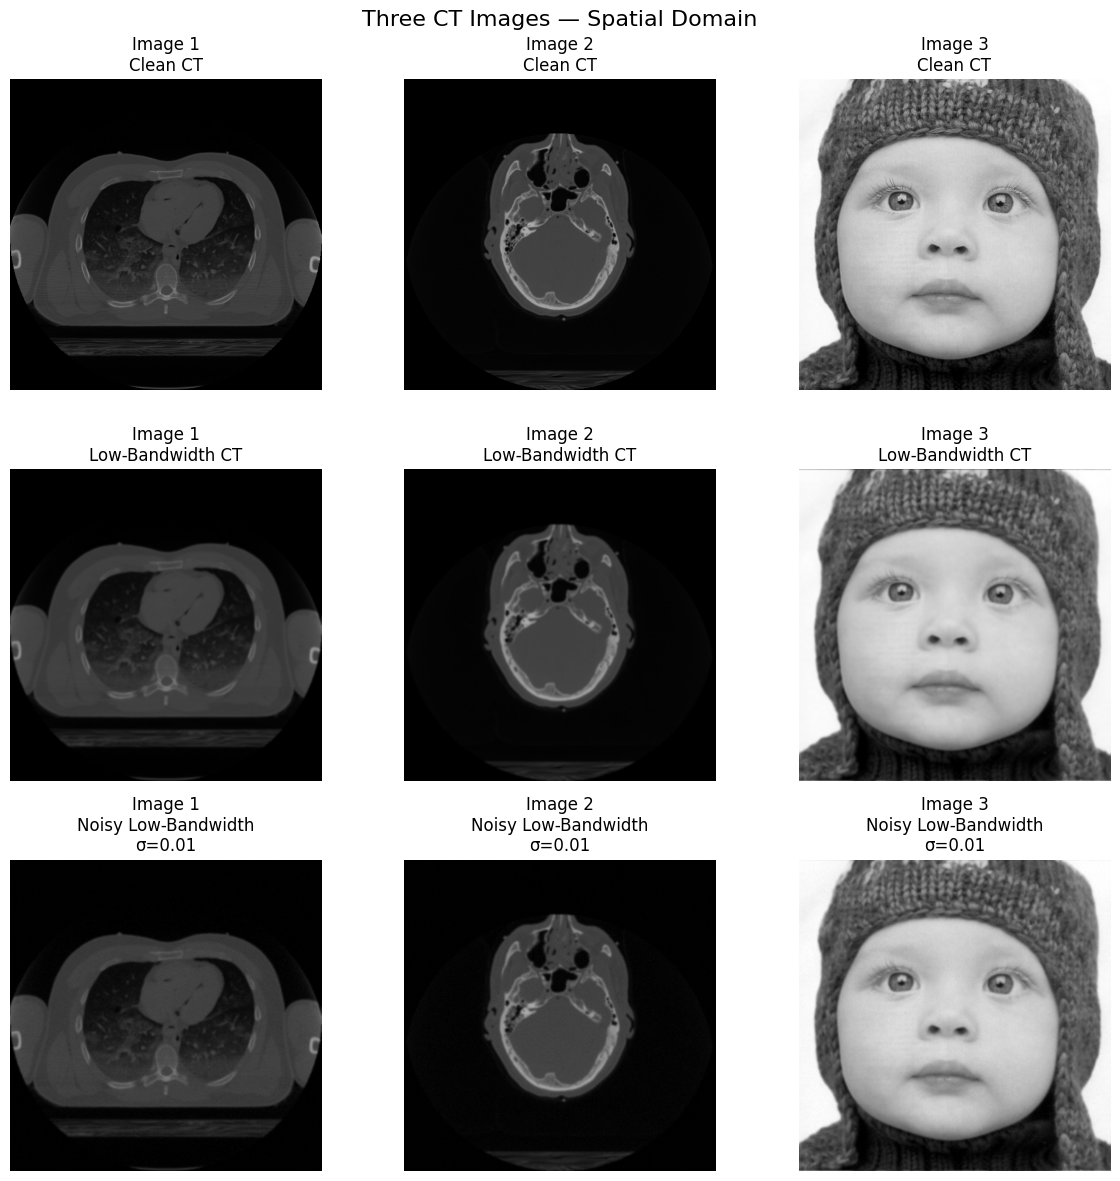

In [49]:

# ============================================================
# 6. Spatial comparison: THREE images at once
# ============================================================

fig, axes = plt.subplots(
    3, 3,
    figsize=(12, 12)
)

row_data = [
    ("clean", "Clean CT"),
    ("low_bandwidth", "Low-Bandwidth CT"),
    ("noisy_low_bandwidth", f"Noisy Low-Bandwidth\nσ={NOISE_STD}")
]

for row, (key, title) in enumerate(row_data):

    for col, item in enumerate(data):

        axes[row, col].imshow(
            item[key],
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[row, col].set_title(
            f"{item['name']}\n{title}"
        )

        axes[row, col].axis("off")

plt.suptitle(
    "Three CT Images — Spatial Domain",
    fontsize=16
)

plt.tight_layout()
plt.show()


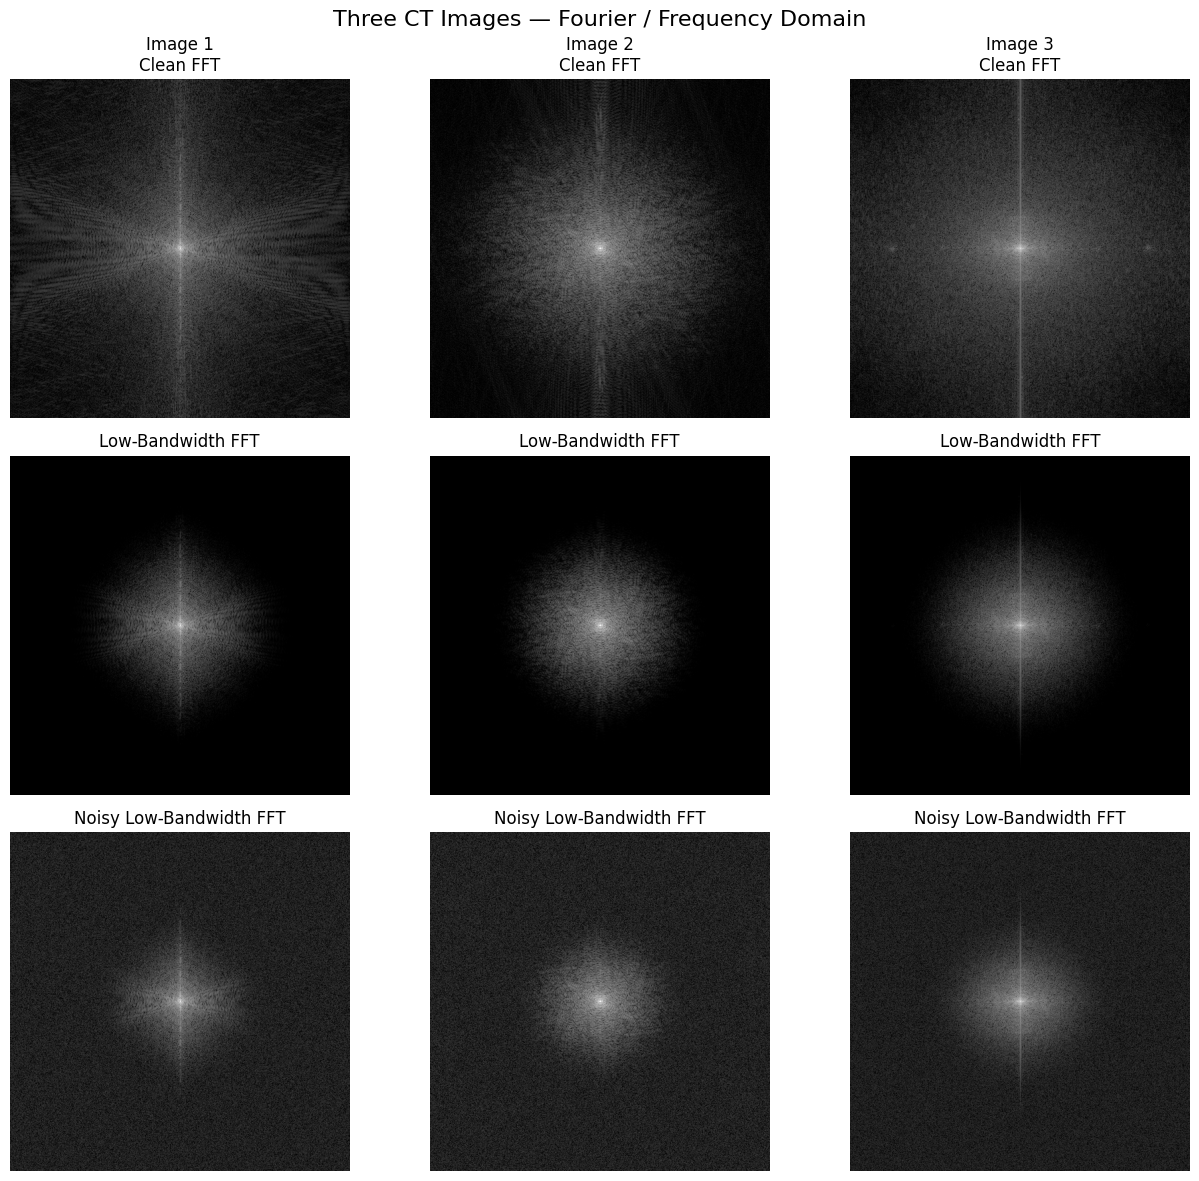

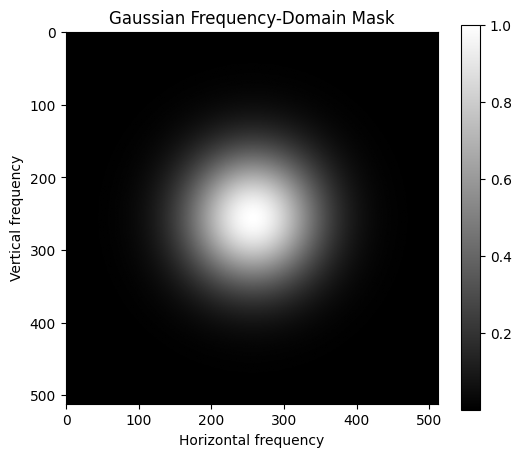

In [50]:

# ============================================================
# 7. Fourier-space comparison: THREE images at once
# ============================================================

# One Gaussian mask is shared because the same degradation
# parameters are used for all three images.

fig, axes = plt.subplots(
    3, 3,
    figsize=(13, 12)
)

for col, item in enumerate(data):

    axes[0, col].imshow(
        log_power_spectrum(item["clean"]),
        cmap="gray"
    )
    axes[0, col].set_title(
        f"{item['name']}\nClean FFT"
    )
    axes[0, col].axis("off")

    axes[1, col].imshow(
        log_power_spectrum(item["low_bandwidth"]),
        cmap="gray"
    )
    axes[1, col].set_title(
        "Low-Bandwidth FFT"
    )
    axes[1, col].axis("off")

    axes[2, col].imshow(
        log_power_spectrum(item["noisy_low_bandwidth"]),
        cmap="gray"
    )
    axes[2, col].set_title(
        "Noisy Low-Bandwidth FFT"
    )
    axes[2, col].axis("off")

plt.suptitle(
    "Three CT Images — Fourier / Frequency Domain",
    fontsize=16
)

plt.tight_layout()
plt.show()


# Show the actual Gaussian frequency mask once.
plt.figure(figsize=(6, 5))
plt.imshow(
    data[0]["gaussian_mask"],
    cmap="gray"
)
plt.title(
    "Gaussian Frequency-Domain Mask"
)
plt.xlabel("Horizontal frequency")
plt.ylabel("Vertical frequency")
plt.colorbar()
plt.show()


In [51]:

# ============================================================
# 9. VDSR INPUT: noisy low-bandwidth 512×512
# ============================================================

# IMPORTANT:
# The VDSR input is the ORIGINAL 512×512 noisy low-bandwidth image.
# There is NO bicubic upsampling before VDSR in this experiment.

vdsr_input_np = np.stack(
    [
        item["noisy_low_bandwidth"]
        for item in data
    ],
    axis=0
)

input_tensor = torch.from_numpy(
    vdsr_input_np
).float().unsqueeze(1).to(DEVICE)

print("VDSR input tensor:", tuple(input_tensor.shape))
print("Expected:", "(3, 1, 512, 512)")

assert input_tensor.shape == (3, 1, 512, 512)

print("\n✓ All THREE images are being sent to VDSR together.")
print("✓ Spatial size entering VDSR = 512×512")


VDSR input tensor: (3, 1, 512, 512)
Expected: (3, 1, 512, 512)

✓ All THREE images are being sent to VDSR together.
✓ Spatial size entering VDSR = 512×512


In [52]:

# ============================================================
# 10. VDSR inference on THREE images together
# ============================================================

model.eval()

with torch.no_grad():

    start = time.time()

    output_tensor = model(
        input_tensor
    )

    elapsed = time.time() - start

print("VDSR output tensor:", tuple(output_tensor.shape))

assert output_tensor.shape == input_tensor.shape

print("✓ VDSR output size =", "512×512")
print(f"✓ Batch inference time = {elapsed:.4f} seconds")
print(f"✓ Average/image       = {elapsed / 3:.4f} seconds")

vdsr_outputs = (
    output_tensor
    .squeeze(1)
    .cpu()
    .numpy()
)

vdsr_outputs = np.clip(
    vdsr_outputs,
    0.0,
    1.0
).astype(np.float32)

for i, item in enumerate(data):
    item["vdsr"] = vdsr_outputs[i]

print()
for item in data:
    print(
        item["name"],
        "→ VDSR output:",
        item["vdsr"].shape
    )


VDSR output tensor: (3, 1, 512, 512)
✓ VDSR output size = 512×512
✓ Batch inference time = 23.8008 seconds
✓ Average/image       = 7.9336 seconds

Image 1 → VDSR output: (512, 512)
Image 2 → VDSR output: (512, 512)
Image 3 → VDSR output: (512, 512)


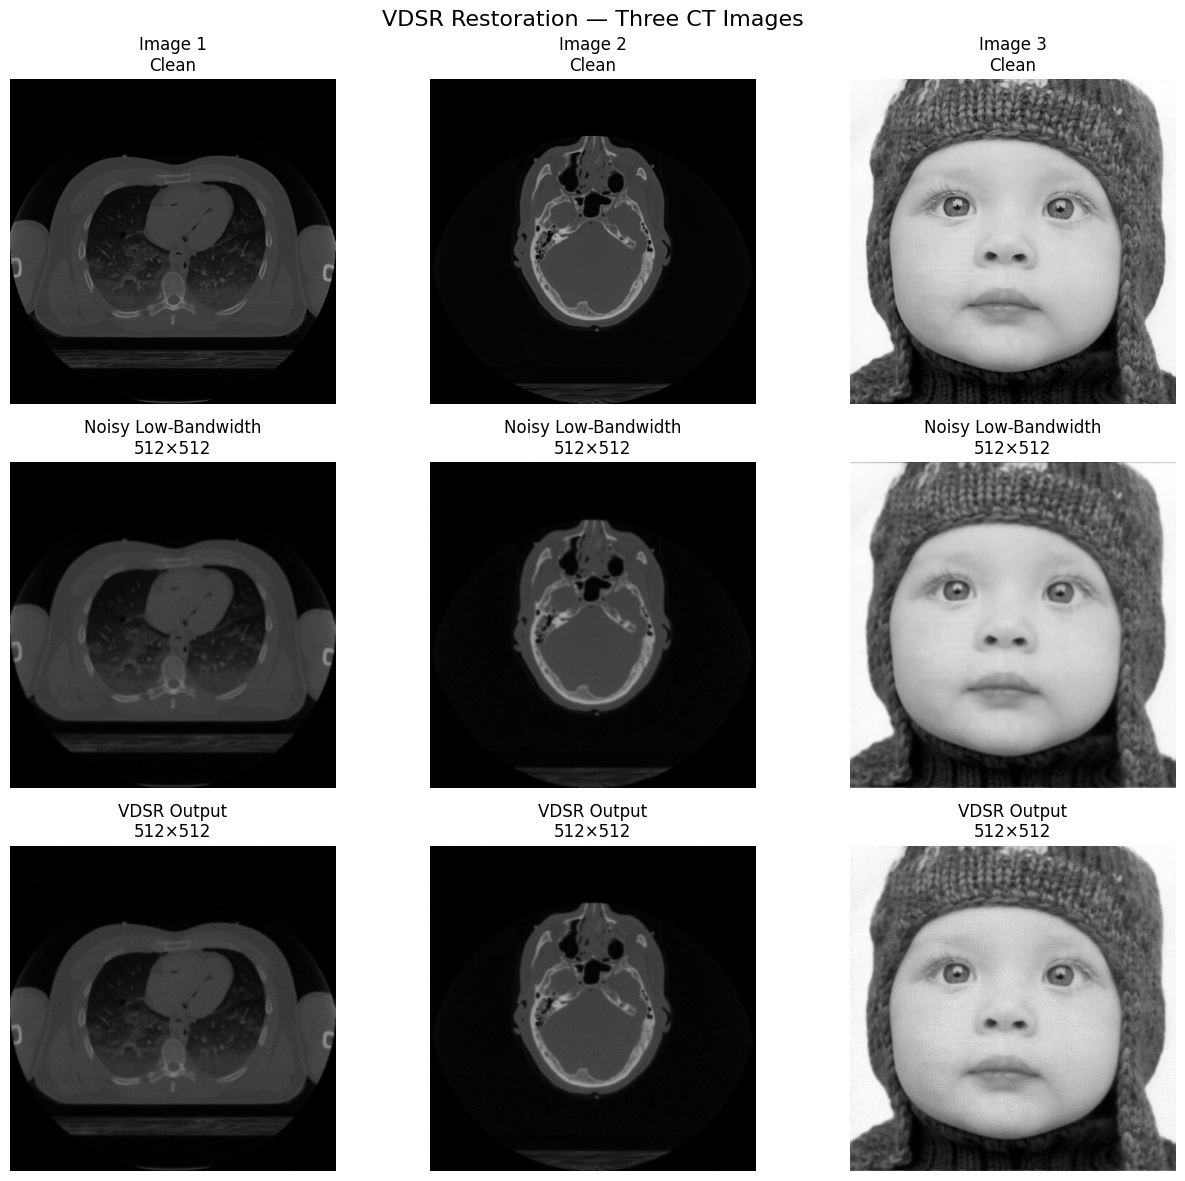

In [53]:

# ============================================================
# 11. Clean vs noisy input vs VDSR — THREE images at once
# ============================================================

fig, axes = plt.subplots(
    3, 3,
    figsize=(13, 12)
)

for col, item in enumerate(data):

    axes[0, col].imshow(
        item["clean"],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[0, col].set_title(
        f"{item['name']}\nClean"
    )
    axes[0, col].axis("off")

    axes[1, col].imshow(
        item["noisy_low_bandwidth"],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1, col].set_title(
        "Noisy Low-Bandwidth\n512×512"
    )
    axes[1, col].axis("off")

    axes[2, col].imshow(
        item["vdsr"],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[2, col].set_title(
        "VDSR Output\n512×512"
    )
    axes[2, col].axis("off")

plt.suptitle(
    "VDSR Restoration — Three CT Images",
    fontsize=16
)

plt.tight_layout()
plt.show()


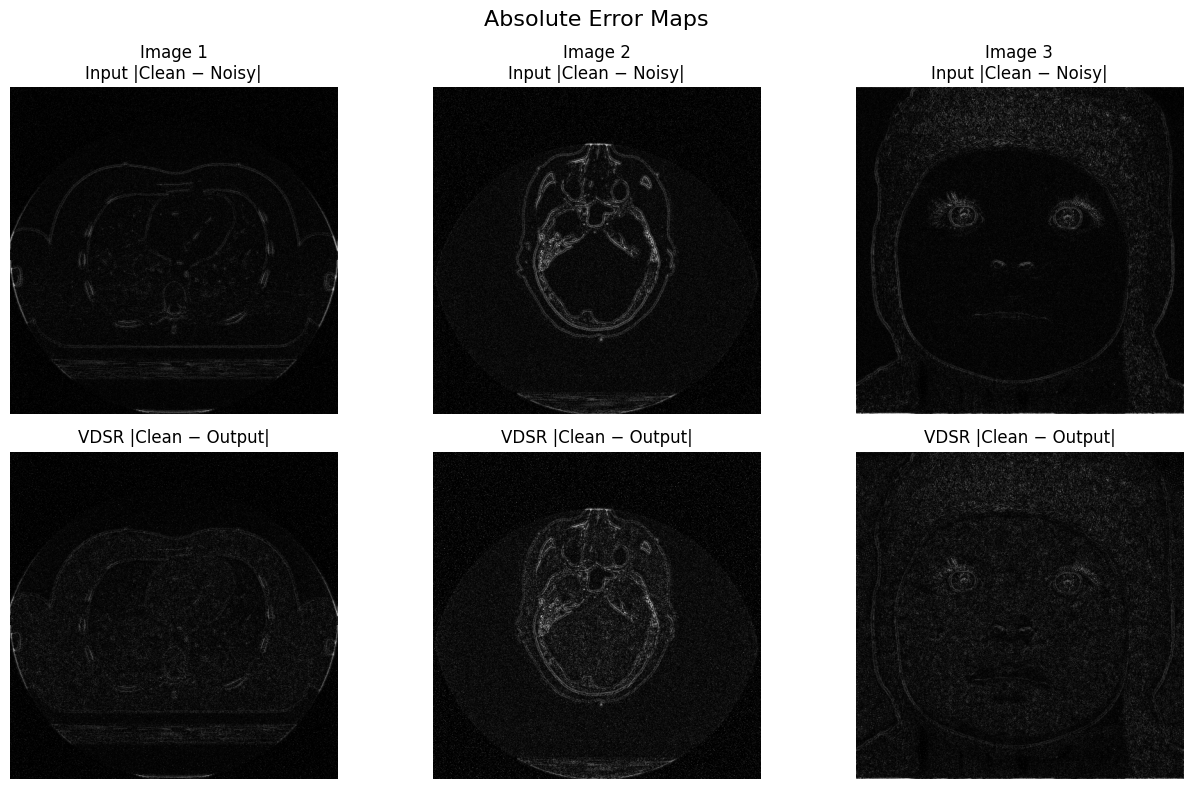

In [54]:

# ============================================================
# 12. Difference / error maps — THREE images at once
# ============================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(13, 8)
)

for col, item in enumerate(data):

    input_error = np.abs(
        item["clean"] -
        item["noisy_low_bandwidth"]
    )

    vdsr_error = np.abs(
        item["clean"] -
        item["vdsr"]
    )

    axes[0, col].imshow(
        input_error,
        cmap="gray"
    )
    axes[0, col].set_title(
        f"{item['name']}\nInput |Clean − Noisy|"
    )
    axes[0, col].axis("off")

    axes[1, col].imshow(
        vdsr_error,
        cmap="gray"
    )
    axes[1, col].set_title(
        "VDSR |Clean − Output|"
    )
    axes[1, col].axis("off")

plt.suptitle(
    "Absolute Error Maps",
    fontsize=16
)

plt.tight_layout()
plt.show()


In [55]:

# ============================================================
# 13. Metrics for all THREE images
# ============================================================

print(
    f"{'Image':<12}"
    f"{'Input MSE':>14}"
    f"{'Input PSNR':>14}"
    f"{'Input SSIM':>14}"
    f"{'VDSR MSE':>14}"
    f"{'VDSR PSNR':>14}"
    f"{'VDSR SSIM':>14}"
)

print("-" * 98)

all_metrics = []

for item in data:

    input_metrics = evaluate_image(
        item["clean"],
        item["noisy_low_bandwidth"]
    )

    vdsr_metrics = evaluate_image(
        item["clean"],
        item["vdsr"]
    )

    all_metrics.append(
        (
            item["name"],
            input_metrics,
            vdsr_metrics
        )
    )

    print(
        f"{item['name']:<12}"
        f"{input_metrics[0]:>14.6f}"
        f"{input_metrics[1]:>14.4f}"
        f"{input_metrics[2]:>14.4f}"
        f"{vdsr_metrics[0]:>14.6f}"
        f"{vdsr_metrics[1]:>14.4f}"
        f"{vdsr_metrics[2]:>14.4f}"
    )


Image            Input MSE    Input PSNR    Input SSIM      VDSR MSE     VDSR PSNR     VDSR SSIM
--------------------------------------------------------------------------------------------------
Image 1           0.000245       36.1168        0.8551      0.000336       34.7361        0.7838
Image 2           0.000223       36.5231        0.8685      0.000258       35.8796        0.8211
Image 3           0.000762       31.1790        0.8701      0.001027       29.8848        0.7294


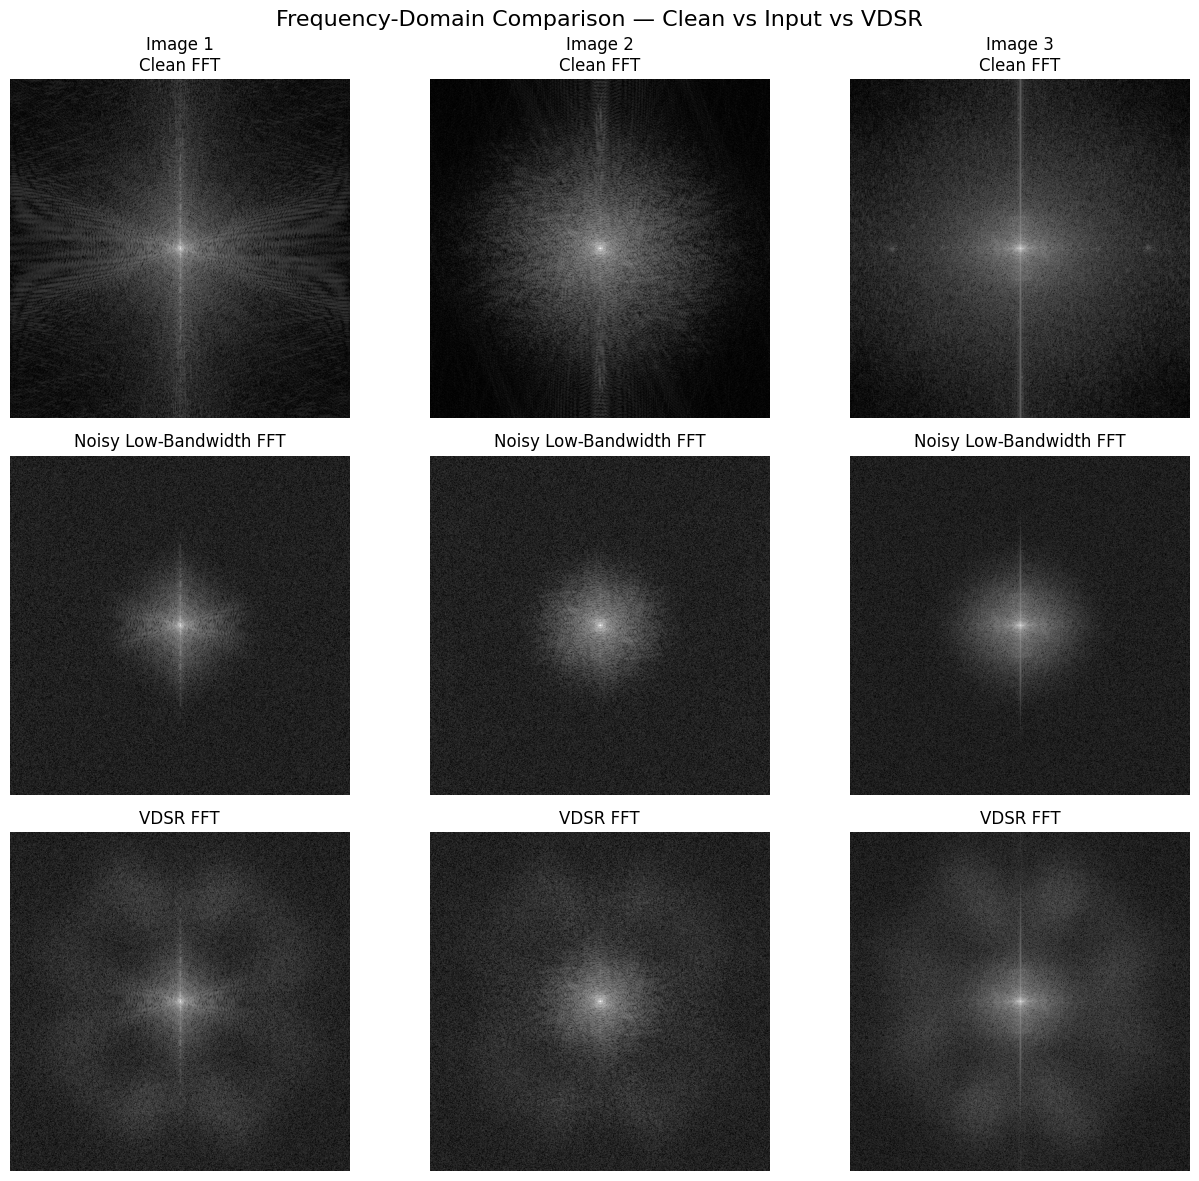

In [56]:

# ============================================================
# 14. Fourier comparison AFTER VDSR — THREE images at once
# ============================================================

fig, axes = plt.subplots(
    3, 3,
    figsize=(13, 12)
)

for col, item in enumerate(data):

    axes[0, col].imshow(
        log_power_spectrum(item["clean"]),
        cmap="gray"
    )
    axes[0, col].set_title(
        f"{item['name']}\nClean FFT"
    )
    axes[0, col].axis("off")

    axes[1, col].imshow(
        log_power_spectrum(item["noisy_low_bandwidth"]),
        cmap="gray"
    )
    axes[1, col].set_title(
        "Noisy Low-Bandwidth FFT"
    )
    axes[1, col].axis("off")

    axes[2, col].imshow(
        log_power_spectrum(item["vdsr"]),
        cmap="gray"
    )
    axes[2, col].set_title(
        "VDSR FFT"
    )
    axes[2, col].axis("off")

plt.suptitle(
    "Frequency-Domain Comparison — Clean vs Input vs VDSR",
    fontsize=16
)

plt.tight_layout()
plt.show()
